In [1]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
train_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v7_start_end.csv"
)

test_dataset = pd.read_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v7_start_end.csv"
)

print(train_dataset.shape)
print(test_dataset.shape)

(242965, 202)
(66060, 202)


In [4]:
behavior_map = {
    "NORMAL1": "NORMAL",
    "NORMAL2": "NORMAL"
}

train_dataset["behavior"] = (
    train_dataset["behavior"]
    .replace(behavior_map)
)

test_dataset["behavior"] = (
    test_dataset["behavior"]
    .replace(behavior_map)
)

print(train_dataset["behavior"].value_counts())
print()
print(test_dataset["behavior"].value_counts())

behavior
NORMAL        116203
AGGRESSIVE     63761
DROWSY         63001
Name: count, dtype: int64

behavior
DROWSY        36143
AGGRESSIVE    15257
NORMAL        14660
Name: count, dtype: int64


In [5]:
target_column = "behavior"

feature_columns = [
    col
    for col in train_dataset.columns
    if col not in [
        "behavior",
        "driver",
        "trip",
        "road_type"
    ]
]

X_train = train_dataset[feature_columns]
X_test = test_dataset[feature_columns]

y_train = train_dataset[target_column]
y_test = test_dataset[target_column]

print(X_train.shape)
print(X_test.shape)

(242965, 198)
(66060, 198)


In [6]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [8]:
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [9]:
rf_pred = rf_model.predict(
    X_test
)

rf_pred[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6396


In [11]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.87      0.76      0.81     15257
      DROWSY       0.83      0.54      0.65     36143
      NORMAL       0.38      0.76      0.51     14660

    accuracy                           0.64     66060
   macro avg       0.69      0.69      0.66     66060
weighted avg       0.74      0.64      0.66     66060



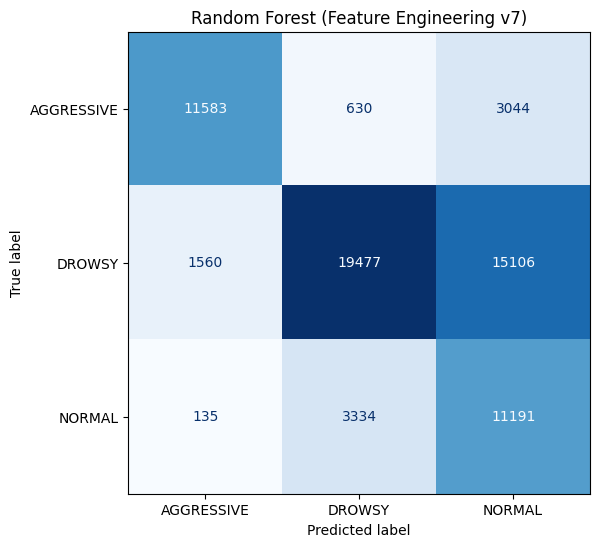

In [13]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest (Feature Engineering v7)")
plt.show()